In [1]:
import os
from pathlib import Path
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import braincell
import brainunit as u
from braincell import Branch, Morpho

print("braincell version:", braincell.__version__)

/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


braincell version: 0.0.8


In [2]:
manual_soma = Branch.from_points(
    points=[(-5.0, 0.0, 0.0), (0.0, 0.0, 0.0), (5.0, 0.0, 0.0)] * u.um,
    radii=[5.0, 5.0, 5.0] * u.um,
    type="soma",
)
manual_tree = Morpho.from_root(manual_soma, name="soma")

manual_tree.soma[0.5].basal_dendrite_0 = Branch.from_points(
    points=[(0.0, 0.0, 0.0), (0.0, 20.0, 0.0), (-5.0, 40.0, 10.0), (-5.0, 55.0, 10.0)] * u.um,
    radii=[1.8, 1.8, 1.4, 1.2] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[0.0].basal_dendrite_1 = Branch.from_points(
    points=[(0.0, 20.0, 0.0), (10.0, 30.0, 10.0), (15.0, 40.0, 10.0)] * u.um,
    radii=[1.8, 1.4, 1.4] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_1[1.0].basal_dendrite_2 = Branch.from_points(
    points=[(15.0, 40.0, 10.0), (30.0, 55.0, 0.0)] * u.um,
    radii=[1.4, 1.0] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_1[1.0].basal_dendrite_3 = Branch.from_points(
    points=[(15.0, 40.0, 10.0), (20.0, 45.0, 20.0)] * u.um,
    radii=[1.4, 1.4] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[1.0].basal_dendrite_4 = Branch.from_points(
    points=[(-5.0, 55.0, 10.0), (-5.0, 60.0, 20.0), (0.0, 70.0, 30.0)] * u.um,
    radii=[1.2, 1.0, 1.0] * u.um,
    type="basal_dendrite",
)
manual_tree.basal_dendrite_0[1.0].basal_dendrite_5 = Branch.from_points(
    points=[(-5.0, 55.0, 10.0), (0.0, 70.0, 0.0)] * u.um,
    radii=[1.2, 0.8] * u.um,
    type="basal_dendrite",
)
manual_tree.soma[0.5].axon_0 = Branch.from_points(
    points=[(0.0 ,0.0, 0.0), (5.0, -20.0, 20.0), (12.0, -20.0, 22.0)] * u.um,
    radii=[1.0, 1.0, 1.0] * u.um,
    type="axon",
)
manual_tree.soma[0.5].axon_1 = Branch.from_points(
    points=[(5.0, -20.0, 20.0), (0.0, -30.0, 30.0)] * u.um,
    radii=[1.0, 0.8] * u.um,
    type="axon",
)



In [ ]:
soma = Branch.from_lengths(lengths= 10*u.um, radii = [10,10]*u.um, type = "soma")
tree = Morpho.from_root(soma)
tree.soma.dend = Branch.from_lengths(lengths= 10*u.um, radii = [2,2]*u.um)
manual_tree.vis2d(mode="frustum")

In [ ]:
tree = Morpho.from_asc('/home/swl/braincell/braincell/io/morpho_files/goc.asc')
import  matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(16, 8))
tree.vis2d(mode="frustum", min_branch_angle_deg=20, ax =ax)

/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


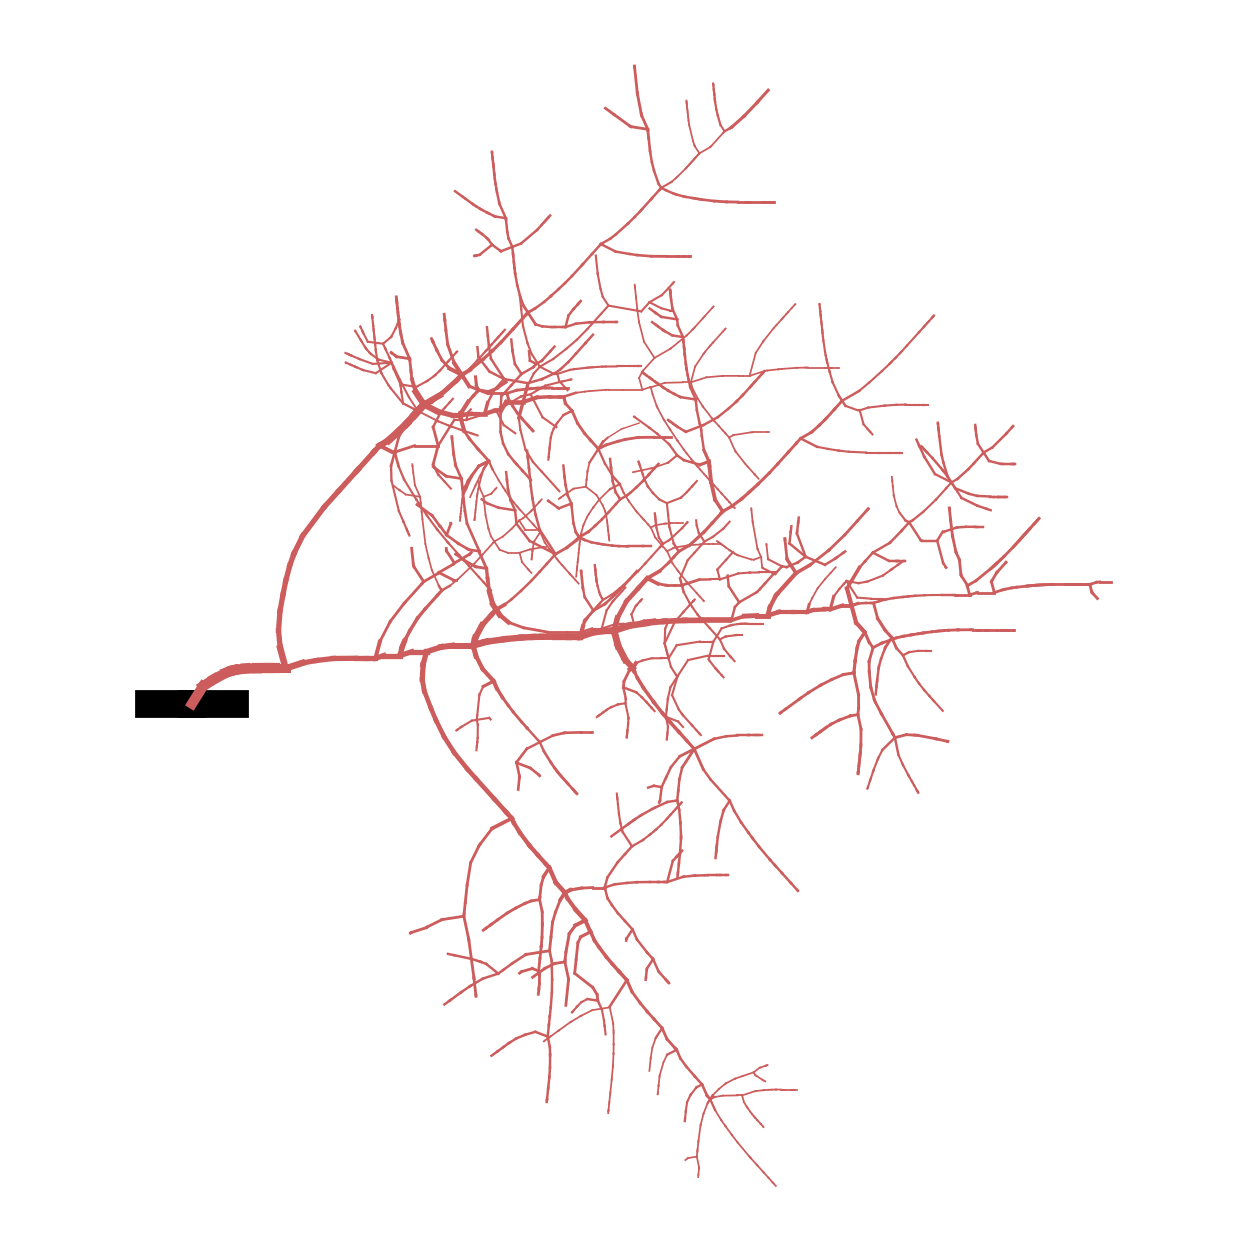

In [ ]:
import matplotlib.pyplot as plt
from braincell import Morpho
from braincell.vis import compare_layouts_2d

tree = Morpho.from_asc("/home/swl/braincell/braincell/io/morpho_files/pc.asc")
fig, ax = plt.subplots(figsize=(16, 16))
tree.vis2d(
    mode="tree",
    layout_family="stem",
    ax=ax,
)
# plt.savefig('pc_projected')
plt.show()



In [3]:
from braincell import (
    Branch,
    CVPolicy,
    CableProperties,
    Cell,
    CurrentClamp,
    DensityMechanism,
    Morpho,
)
soma = Branch.from_lengths(lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma")
left = Branch.from_lengths(lengths=[20.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite")
right = Branch.from_lengths(lengths=[20.0] * u.um, radii=[2.0, 1.0] * u.um, type="basal_dendrite")
tree = Morpho.from_root(soma, name="soma")
tree.attach(parent="soma", child_branch=left, child_name="left", parent_x=0.5)
tree.attach(parent="soma", child_branch=right, child_name="right", parent_x=0.5)

cell = Cell(tree, cv_policy=CVPolicy(cv_per_branch=1))
axial_tree = cell.axial_tree(max_group_size=1)

In [9]:
axial_tree.point(0)

AxialPoint(id=0, branch_id=0, point_type='root_boundary', owner_cv=None, parent_id=None, children_ids=(1,))